Check CUDA version and that GPU is working in cellpose and import other libraries.

In [53]:
!nvcc --version
!nvidia-smi

import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from cellpose import core, utils, io, models, metrics
from glob import glob

use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

/bin/bash: nvcc: command not found
Fri Jun 21 00:48:21 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A6000               On  | 00000000:1A:00.0 Off |                  Off |
| 30%   33C    P8              22W / 300W |   6028MiB / 49140MiB |      0%      Default |
|                                         |                      |                  N/A |
+--------------------------------

In [3]:
import skimage.io

# read the image

DIRECTORY = "/home/MORGRIDGE/vagrawal/vidit/dataset_v2"
files = os.listdir("/home/MORGRIDGE/vagrawal/vidit/dataset_v2")
filelist = [file for file in files if not file.startswith('.')]
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

ground_truth_images = []
phenotype_images = []

for i in annot_files:
    ground_truth_images.append(DIRECTORY + '/' + i.replace('phenotype_outlines.png', 'phenotype.tif'))
    phenotype_images.append(DIRECTORY + '/' + i.replace('phenotype_outlines.png', 'nuclei-clean.tif'))

print(ground_truth_images)
print(phenotype_images)


['/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-10.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-110.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-130.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-150.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-170.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-190.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-30.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-50.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-70.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-90.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype.tif

In [62]:
#copy images to another folder

for i in range(len(ground_truth_images)):
    shutil.copy(ground_truth_images[i], '/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test')
    shutil.copy(phenotype_images[i], '/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test')
    break

In [27]:
#@markdown ###Path to images and masks:

train_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train" #@param {type:"string"}
test_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test" #@param {type:"string"}
#Define where the patch file will be saved
base = "/content"

# model name and path
#@markdown ###Name of the pretrained model to start from and new model name:
from cellpose import models
initial_model = "cyto" #@param ["cyto", "cyto3","nuclei","tissuenet_cp3", "livecell_cp3", "yeast_PhC_cp3", "yeast_BF_cp3", "bact_phase_cp3", "bact_fluor_cp3", "deepbacs_cp3", "scratch"]
model_name = "new_model_cyto" #@param {type:"string"}

# other parameters for training.
#@markdown ###Training Parameters:
#@markdown Number of epochs:
n_epochs =  100#@param {type:"number"}

Channel_to_use_for_training = "Grayscale" #@param ["Grayscale", "Blue", "Green", "Red"]

# @markdown ###If you have a secondary channel that can be used for training, for instance nuclei, choose it here:

Second_training_channel= "None" #@param ["None", "Blue", "Green", "Red"]


#@markdown ###Advanced Parameters

Use_Default_Advanced_Parameters = True #@param {type:"boolean"}
#@markdown ###If not, please input:
learning_rate = 0.1 #@param {type:"number"}
weight_decay = 0.0001 #@param {type:"number"}

if (Use_Default_Advanced_Parameters):
  print("Default advanced parameters enabled")
  learning_rate = 0.1
  weight_decay = 0.0001

#here we check that no model with the same name already exist, if so delete
model_path = train_dir + 'models/'
if os.path.exists(model_path+'/'+model_name):
  print("!! WARNING: "+model_name+" already exists and will be deleted in the following cell !!")

if len(test_dir) == 0:
  test_dir = None

# Here we match the channel to number
if Channel_to_use_for_training == "Grayscale":
  chan = 0
elif Channel_to_use_for_training == "Blue":
  chan = 3
elif Channel_to_use_for_training == "Green":
  chan = 2
elif Channel_to_use_for_training == "Red":
  chan = 1


if Second_training_channel == "Blue":
  chan2 = 3
elif Second_training_channel == "Green":
  chan2 = 2
elif Second_training_channel == "Red":
  chan2 = 1
elif Second_training_channel == "None":
  chan2 = 0

if initial_model=='scratch':
  initial_model = 'None'

Default advanced parameters enabled


In [ ]:
import glob
import skimage
import matplotlib.pyplot as plt
import numpy as np
import scipy
#Display the .tif images in the folder
file_path = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train/20X_c0-DAPI_A1_Tile-10.nuclei-clean.tif"

train_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train"
test_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test"

train_label = []

for file_path in glob.glob(train_dir + '/*nuclei-clean.tif'):
  img = skimage.io.imread(file_path, as_gray=True)
  seg = img > 0
  plt.imshow(seg, cmap='gray')
  plt.show()

  mask = scipy.ndimage.binary_fill_holes(img) ^ img
  # Transform annotations to labels
  labels = skimage.measure.label(mask)
  labels = skimage.morphology.dilation(labels)  # recover object edge
  # Reshape to (1, 2960, 2960)
  #labels = np.expand_dims(labels, axis=0)
  # Display the shape of the labels
  np.save(file_path.replace('nuclei-clean.tif', 'phenotype_seg.npy'), labels)
  train_label.append(labels)

  # Display the labels and the image
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  ax[0].imshow(labels, cmap='gray')
  ax[1].imshow(img, cmap='gray')
  plt.show()


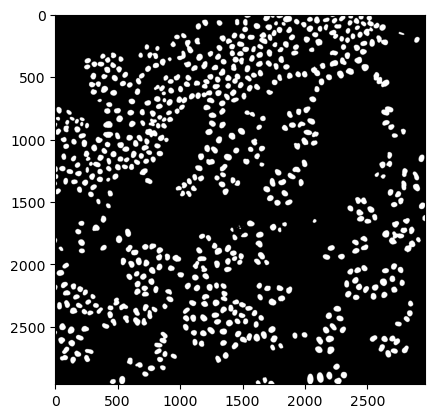

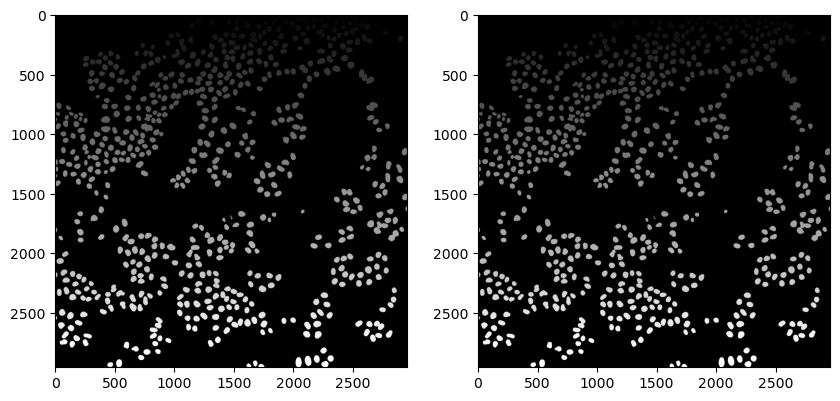

1


In [63]:
test_label = []
import glob
import scipy
for file_path in glob.glob(test_dir + '/*nuclei-clean.tif'):
  img = skimage.io.imread(file_path, as_gray=True)
  seg = img > 0
  plt.imshow(seg, cmap='gray')
  plt.show()

  mask = scipy.ndimage.binary_fill_holes(img) ^ img
  # Transform annotations to labels
  labels = skimage.measure.label(mask)
  labels = skimage.morphology.dilation(labels)  # recover object edge
  # Reshape to (1, 2960, 2960)
  #labels = np.expand_dims(labels, axis=0)
  # Display the shape of the labels
  np.save(file_path.replace('.tif', '_seg.npy'), labels)
  test_label.append(labels)

  # Display the labels and the image
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  ax[0].imshow(labels, cmap='gray')
  ax[1].imshow(img, cmap='gray')
  plt.show()

print(len(test_label))

In [13]:
train_label = []
test_label = []
import glob
for file_path in glob.glob(train_dir + '/*phenotype_seg.npy'):
    img = np.load(file_path)
    train_label.append(img)


#make it N, C, H, W
train_data = []

for file_path in glob.glob(train_dir + '/*phenotype.tif'):
    img = skimage.io.imread(file_path, as_gray=True)
    # Make the image N, C, H, W
    img = np.expand_dims(img, axis=0)  # Add channel dimension (C=1)
    img = img.tolist()  # Convert numpy array to a nested list
    train_data.append(img)



#make both arrays numpy
train_data = np.array(train_data)
train_label = np.array(train_label)

print(train_data.shape)
print(train_label.shape)


(17, 1, 2960, 2960)
(17, 2960, 2960)


In [87]:
test_label = []
import glob
for file_path in glob.glob(test_dir + '/*phenotype_seg.npy'):
    img = np.load(file_path, allow_pickle=True)
    test_label.append(img)


#make it N, C, H, W
test_data = []

for file_path in glob.glob(test_dir + '/*phenotype.tif'):
    img = skimage.io.imread(file_path, as_gray=True)
    # Make the image N, C, H, W
    img = np.expand_dims(img, axis=0)  # Add channel dimension (C=1)
    img = img.tolist()  # Convert numpy array to a nested list
    test_data.append(img)

print(len(test_data))
print(len(test_label))


#make both arrays numpy
test_data = np.array(test_data)
test_label = np.array(test_label)


print(test_data.shape)
print(test_label.shape)

1
1
(1, 1, 2960, 2960)
(1,)


Here's what the command to train would be on the command line -- make sure if you run this locally to correct the paths for your local computer.

## Train new model

Using settings from form above, train model in notebook.

In [89]:
from cellpose import train

# start logger (to see training across epochs)
logger = io.logger_setup()

# DEFINE CELLPOSE MODEL (without size model)
model = models.CellposeModel(gpu=use_GPU, model_type=initial_model)

# set channels
channels = [0, 0]

#Train data is N, C, H, W
#Labels are N, H, W

# get files
#output = io.load_train_test_data(train_dir=train_dir, mask_filter='_seg.npy')

# dimensions of train_data (18, 2960, 2960)

#train_data, _, train_image_names, _, _, _ = output

#print(len(train_data[0][0]))
#print(len(train_label))

#print(type(train_data))

new_model_path = train.train_seg(model.net, train_data=train_data,
                              train_labels=train_label,
                              #test_data=test_data,
                              #test_labels=test_label,
                              channels=channels,
                              save_path=train_dir,
                              n_epochs=300,
                              learning_rate=0.1,
                              weight_decay=weight_decay,
                              momentum=0.5,
                              SGD=True,
                              nimg_per_epoch=8,
                              normalize=False,
                              model_name=model_name)



# diameter of labels in training images
diam_labels = model.net.diam_labels.item()

2024-06-21 01:48:44,885 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/vagrawal/.cellpose/run.log
2024-06-21 01:48:44,886 [INFO] 
cellpose version: 	3.0.9 
platform:       	linux 
python version: 	3.11.0 
torch version:  	2.3.0
2024-06-21 01:48:44,886 [INFO] >> cyto << model set to be used
2024-06-21 01:48:44,904 [INFO] ** TORCH CUDA version installed and working. **
2024-06-21 01:48:44,904 [INFO] >>>> using GPU
2024-06-21 01:48:44,969 [INFO] >>>> loading model /home/MORGRIDGE/vagrawal/.cellpose/models/cytotorch_0
2024-06-21 01:48:45,016 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2024-06-21 01:48:45,016 [INFO] computing flows for labels


100%|██████████| 17/17 [00:22<00:00,  1.29s/it]

2024-06-21 01:49:07,473 [INFO] >>> computing diameters



100%|██████████| 17/17 [00:00<00:00, 41.54it/s]

2024-06-21 01:49:07,884 [INFO] >>> using channels [0, 0]


2024-06-21 01:49:08,839 [INFO] >>> n_epochs=300, n_train=17, n_test=None
2024-06-21 01:49:08,840 [INFO] >>> SGD, learning_rate=0.10000, weight_decay=0.00010, momentum=0.500
2024-06-21 01:49:08,842 [INFO] >>> saving model to /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train/models/new_model_cyto
2024-06-21 01:49:11,581 [INFO] 0, train_loss=4.7843, test_loss=0.0000, LR=0.0000, time 2.74s
2024-06-21 01:49:25,164 [INFO] 5, train_loss=3.8875, test_loss=0.0000, LR=0.0556, time 16.32s
2024-06-21 01:49:38,982 [INFO] 10, train_loss=2.1857, test_loss=0.0000, LR=0.1000, time 30.14s
2024-06-21 01:50:06,407 [INFO] 20, train_loss=2.0172, test_loss=0.0000, LR=0.1000, time 57.57s
2024-06-21 01:50:34,120 [INFO] 30, train_loss=1.9481, test_loss=0.0000, LR=0.1000, time 85.28s
2024-06-21 01:51:00,682 [INFO] 40, train_loss=1.9010, test_loss=0.0000, LR=0.1000, time 111.84s
2024-06-21 01:51:27,761 [INFO] 50, train_loss=1.9419, test_loss=0.0000, LR=0.1000, time 138.92s
2024-06-21 01:51:55,742 [INFO] 60, tra

## Evaluate on test data (optional)

If you have test data, check performance

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

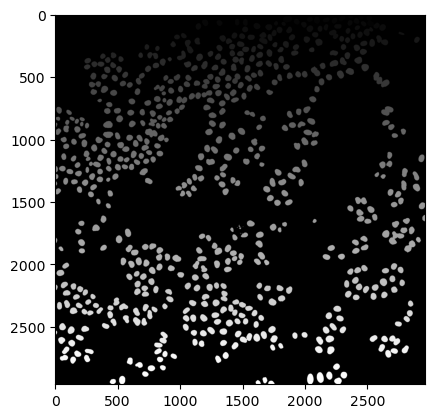

In [77]:
true_mask = np.load("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test/20X_c0-DAPI_A1_Tile-10.phenotype.npy", allow_pickle=True)
plt.imshow(true_mask, cmap='gray')

print(np.unique(true_mask))
plt.show()

In [79]:
# get files (during training, test_data is transformed so we will load it again)


test_label = []
import glob
for file_path in glob.glob(test_dir + '/*phenotype_seg.npy'):
    img = np.load(file_path, allow_pickle=True)
    test_label.append(img)


#make it N, C, H, W
test_data = []

for file_path in glob.glob(test_dir + '/*phenotype.tif'):
    img = skimage.io.imread(file_path, as_gray=True)
    # Make the image N, C, H, W
    img = np.expand_dims(img, axis=0)  # Add channel dimension (C=1)
    img = img.tolist()  # Convert numpy array to a nested list
    test_data.append(img)

print(len(test_data))
print(len(test_label))


#make both arrays numpy
test_data = np.array(test_data)
test_label = np.array(test_label)

print(test_data.shape)
print(test_label.shape)




#output = io.load_train_test_data(test_dir, mask_filter='_seg.npy')
#test_data, _ = output[:2]

# run model on test images
masks = model.eval(test_data,
                   channels=[0, 0],
                   diameter=diam_labels)[0]

print(type(masks))


'''
# check performance using ground truth labels
ap = metrics.average_precision(test_label, masks)[0]
print('')
print(f'>>> average precision at iou threshold 0.5 = {ap[:,0].mean():.3f}')
'''


1
1
(1, 1, 2960, 2960)
(1,)
2024-06-21 01:28:50,769 [INFO] No cell pixels found.
<class 'numpy.ndarray'>


"\n# check performance using ground truth labels\nap = metrics.average_precision(test_label, masks)[0]\nprint('')\nprint(f'>>> average precision at iou threshold 0.5 = {ap[:,0].mean():.3f}')\n"

In [80]:
!cellpose --dir . --pretrained_model ../train/models/new_model_cyto --chan 0 --chan2 0 --save_png --verbose

2024-06-21 01:28:59,925 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/vagrawal/.cellpose/run.log
2024-06-21 01:28:59,925 [INFO] 
cellpose version: 	3.0.11.dev1+g84344b0 
platform:       	linux 
python version: 	3.11.0 
torch version:  	2.3.0
2024-06-21 01:28:59,925 [INFO] >>>> using CPU
2024-06-21 01:28:59,926 [WARNING] pretrained model has incorrect path, using cyto3
Traceback (most recent call last):
  File "/home/MORGRIDGE/vagrawal/vidit/anaconda3/bin/cellpose", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/scr/vidit/anaconda3/lib/python3.11/site-packages/cellpose/__main__.py", line 134, in main
    image_names = io.get_image_files(
                  ^^^^^^^^^^^^^^^^^^^
  File "/scr/vidit/anaconda3/lib/python3.11/site-packages/cellpose/io.py", line 313, in get_image_files
    raise ValueError(
ValueError: ERROR: no images in --dir folder with extensions .png, .jpg, .jpeg, .tif, .tiff


TypeError: Image data of dtype object cannot be converted to float

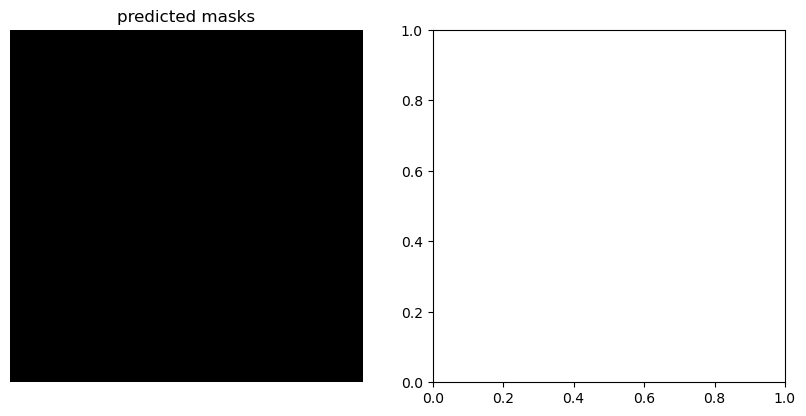

In [81]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(masks, cmap='gray')
plt.title('predicted masks')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(test_label[0], cmap='gray')
plt.title('true masks')
plt.axis('off')
plt.show()

print(masks)

plot masks

In [ ]:

plt.figure(figsize=(12,8), dpi=150)
for k,im in enumerate(test_data):
    img = im.copy()
    plt.subplot(3,len(train_files), k+1)
    img = np.vstack((img, np.zeros_like(img)[:1]))
    img = img.transpose(1,2,0)
    plt.imshow(img)
    plt.axis('off')
    if k==0:
        plt.title('image')

    plt.subplot(3,len(train_files), len(train_files) + k+1)
    plt.imshow(masks[k])
    plt.axis('off')
    if k==0:
        plt.title('predicted labels')

    plt.subplot(3,len(train_files), 2*len(train_files) + k+1)
    plt.imshow(test_labels[k])
    plt.axis('off')
    if k==0:
        plt.title('true labels')
plt.tight_layout()

# Use custom model to segment images

Take custom trained model from above, or upload your own model to google drive / colab runtime.

## Parameters

In [ ]:
# model name and path

#@markdown ###Custom model path (full path):

model_path = "human_in_the_loop/train/models/CP_tissuenet" #@param {type:"string"}

#@markdown ###Path to images:

dir = "human_in_the_loop/test" #@param {type:"string"}

#@markdown ###Channel Parameters:

Channel_to_use_for_segmentation = "Green" #@param ["Grayscale", "Blue", "Green", "Red"]

# @markdown If you have a secondary channel that can be used, for instance nuclei, choose it here:

Second_segmentation_channel= "Red" #@param ["None", "Blue", "Green", "Red"]


# Here we match the channel to number
if Channel_to_use_for_segmentation == "Grayscale":
  chan = 0
elif Channel_to_use_for_segmentation == "Blue":
  chan = 3
elif Channel_to_use_for_segmentation == "Green":
  chan = 2
elif Channel_to_use_for_segmentation == "Red":
  chan = 1


if Second_segmentation_channel == "Blue":
  chan2 = 3
elif Second_segmentation_channel == "Green":
  chan2 = 2
elif Second_segmentation_channel == "Red":
  chan2 = 1
elif Second_segmentation_channel == "None":
  chan2 = 0

#@markdown ### Segmentation parameters:

#@markdown diameter of cells (set to zero to use diameter from training set):
diameter =  0#@param {type:"number"}
#@markdown threshold on flow error to accept a mask (set higher to get more cells, e.g. in range from (0.1, 3.0), OR set to 0.0 to turn off so no cells discarded):
flow_threshold = 0.4 #@param {type:"slider", min:0.0, max:3.0, step:0.1}
#@markdown threshold on cellprob output to seed cell masks (set lower to include more pixels or higher to include fewer, e.g. in range from (-6, 6)):
cellprob_threshold=0 #@param {type:"slider", min:-6, max:6, step:1}


if you're using the example test data we'll copy it to a new folder

In [ ]:
src = 'human_in_the_loop/test'
if dir[:len(src)] == src:
    files = io.get_image_files(dir, '_masks')
    dir = 'human_in_the_loop/eval/'
    os.makedirs(dir, exist_ok=True)
    for f in files:
        dst = dir + os.path.split(f)[1]
        print(f'{f} > {dst}')
        shutil.copyfile(f, dst)

Here's what the command to train would be on the command line -- make sure if you run this locally to correct the paths for your local computer.

In [ ]:
run_str = f'python -m cellpose --use_gpu --verbose --dir {dir} --pretrained_model {model_path} --chan {chan} --chan2 {chan2} --diameter {diameter} --flow_threshold {flow_threshold} --cellprob_threshold {cellprob_threshold}'
print(run_str)

## run custom model

how to run the custom model in a notebook

In [ ]:
# gets image files in dir (ignoring image files ending in _masks)
files = io.get_image_files(dir, '_masks')
print(files)
images = [io.imread(f) for f in files]

# declare model
model = models.CellposeModel(gpu=True,
                             model_type='nuclei')

# use model diameter if user diameter is 0
diameter = model.diam_labels if diameter==0 else diameter

# run model on test images
masks, flows, styles = model.eval(images,
                                  channels=[chan, chan2],
                                  diameter=diameter,
                                  flow_threshold=flow_threshold,
                                  cellprob_threshold=cellprob_threshold
                                  )

## save output to *_seg.npy

you will see the files save in the Files tab and you can download them from there

In [ ]:
from cellpose import io

io.masks_flows_to_seg(images,
                      masks,
                      flows,
                      files,
                      channels=[chan, chan2],
                      diams=diameter*np.ones(len(masks)),
                      )

## save output masks to tiffs/pngs or txt files for imageJ

In [ ]:
io.save_masks(images,
              masks,
              flows,
              files,
              channels=[chan, chan2],
              png=True, # save masks as PNGs and save example image
              tif=True, # save masks as TIFFs
              save_txt=True, # save txt outlines for ImageJ
              save_flows=False, # save flows as TIFFs
              save_outlines=False, # save outlines as TIFFs
              save_mpl=True # make matplotlib fig to view (WARNING: SLOW W/ LARGE IMAGES)
              )


In [ ]:
f = files[0]
plt.figure(figsize=(12,4), dpi=300)
plt.imshow(io.imread(os.path.splitext(f)[0] + '_cp_output.png'))
plt.axis('off')